In [62]:
print("Hello World")

Hello World


In [63]:
# ===============================
# 1. IMPORT LIBRARIES (NO SKLEARN)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 2. LINEAR REGRESSION CLASS
# ===============================
class LinearRegression:

    def __init__(self, learning_rate=0.01, no_of_iterations=1500):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):

        self.m, self.n = X.shape
        self.w = np.zeros(self.n)
        self.b = 0

        self.X = X
        self.Y = Y
        self.costs = []

        for _ in range(self.no_of_iterations):
            self.update_weights()

    def update_weights(self):

        Y_pred = self.predict(self.X)

        dw = -(2 / self.m) * self.X.T.dot(self.Y - Y_pred)
        db = -(2 / self.m) * np.sum(self.Y - Y_pred)

        self.w -= self.learning_rate * dw
        self.b -= self.learning_rate * db

        cost = np.mean((self.Y - Y_pred) ** 2)
        self.costs.append(cost)

    def predict(self, X):
        return X.dot(self.w) + self.b


In [64]:
df = pd.read_csv('files/co2.csv')

print(df.head())
print(df.shape)
print(df.isnull().sum())


    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

In [65]:
num_df = df.select_dtypes(include=['int64', 'float64'])


In [66]:
corr_matrix = num_df.corr()
print(corr_matrix)


                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption City (L/100 km)        0.831379   0.800702   
Fuel Consumption Hwy (L/100 km)         0.761526   0.715252   
Fuel Consumption Comb (L/100 km)        0.817060   0.780534   
Fuel Consumption Comb (mpg)            -0.757854  -0.719321   
CO2 Emissions(g/km)                     0.851145   0.832644   

                                  Fuel Consumption City (L/100 km)  \
Engine Size(L)                                            0.831379   
Cylinders                                                 0.800702   
Fuel Consumption City (L/100 km)                          1.000000   
Fuel Consumption Hwy (L/100 km)                           0.948180   
Fuel Consumption Comb (L/100 km)                          0.993810   
Fuel Consumption Comb (mpg)                              -0.927059   
CO2 E

In [67]:
target = 'CO2 Emissions(g/km)'

target_corr = corr_matrix[target].sort_values(ascending=False)
print(target_corr)





CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


In [68]:
candidates = target_corr[
    (target_corr.index != target) &
    (abs(target_corr) >= threshold)
].index.tolist()


In [69]:
final_features = []
redundancy_threshold = 0.9

for feature in candidates:
    redundant = False
    for selected in final_features:
        if abs(corr_matrix.loc[feature, selected]) >= redundancy_threshold:

            # Compare average correlation with other fuel-related features
            group = ['Fuel Consumption City (L/100 km)',
                     'Fuel Consumption Hwy (L/100 km)',
                     'Fuel Consumption Comb (L/100 km)']

            if feature in group and selected in group:
                feature_score = corr_matrix.loc[feature, group].abs().mean()
                selected_score = corr_matrix.loc[selected, group].abs().mean()

                if feature_score <= selected_score:
                    redundant = True
                    break
            else:
                if abs(target_corr[feature]) <= abs(target_corr[selected]):
                    redundant = True
                    break

    if not redundant:
        final_features.append(feature)

print("Final selected features (fully automatic):")
print(final_features)


Final selected features (fully automatic):
['Fuel Consumption City (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Engine Size(L)']


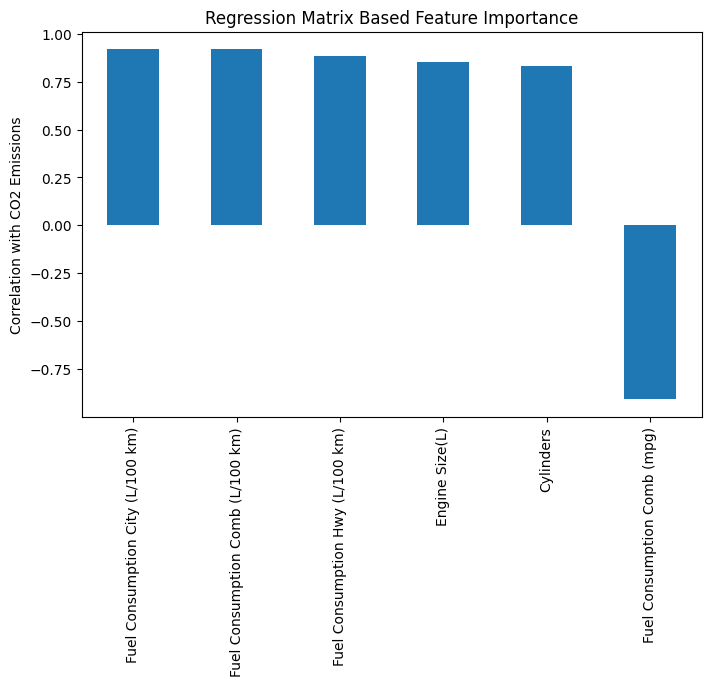

In [70]:
plt.figure(figsize=(8,5))
target_corr.drop(target).plot(kind='bar')
plt.ylabel("Correlation with CO2 Emissions")
plt.title("Regression Matrix Based Feature Importance")
plt.show()


In [71]:
X = df[final_features].values
Y = df[target].values



In [72]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std


In [73]:
np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.7 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
X_test = X[test_idx]

Y_train = Y[train_idx]
Y_test = Y[test_idx]


In [74]:
model = LinearRegression(learning_rate=0.01, no_of_iterations=1500)
model.fit(X_train, Y_train)

print("Learned weights:", model.w)
print("Learned bias:", model.b)


Learned weights: [17.91141772 21.34150389 17.08271427]
Learned bias: 250.419231112296


In [75]:
Y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(np.mean((Y_test - Y_pred) ** 2))

# R-squared
ss_total = np.sum((Y_test - np.mean(Y_test)) ** 2)
ss_res = np.sum((Y_test - Y_pred) ** 2)
r2 = 1 - ss_res / ss_total

print("RMSE:", rmse)
print("R-squared:", r2)


RMSE: 20.252478138469716
R-squared: 0.8850531942871169


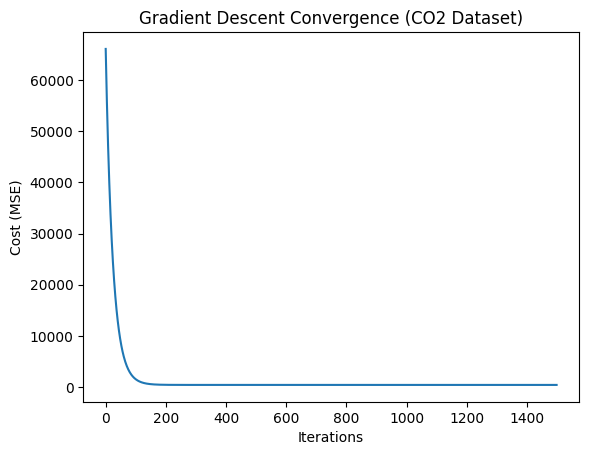

In [76]:
plt.plot(model.costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence (CO2 Dataset)")
plt.show()
